# Visualisation exploratoire du modele MOGEC

Ce notebook privilegie plusieurs petites visualisations simples plutot qu'un tableau de bord unique.
Il sert a comprendre :
- la population presente a `T0` ;
- la dynamique horaire globale ;
- les types de batiments destination ;
- les principaux poles d'arrivee.


In [5]:
from pathlib import Path
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "config.yaml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.pipeline import load_config, run_pipeline
from src.visualization.exploration import (
    build_destination_assignments,
    destination_type_counts,
    hourly_population_curve,
    role_destination_heatmap,
    summarize_population_metrics,
    top_destination_buildings,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)


CONFIG_PATH = ROOT / "config.yaml"
config = load_config(CONFIG_PATH)
output_cfg = config["data_paths"]["output"]
export_key = "final_export" if "final_export" in output_cfg else "population_gpkg"
EXPORT_PATH = ROOT / output_cfg[export_key]


## Chargement des donnees

Pour les destinations, il faut utiliser le `GeoDataFrame` complet du pipeline car il contient les foyers et les affectations internes.
Le GeoPackage exporte reste utile pour relire rapidement les sorties finales.


In [6]:
gdf_model = run_pipeline(config)
gdf_export = gpd.read_file(EXPORT_PATH) if EXPORT_PATH.exists() else gdf_model.copy()

assignments = build_destination_assignments(gdf_model)
metrics = summarize_population_metrics(gdf_model, assignments)
hourly = hourly_population_curve(gdf_model)
type_counts = destination_type_counts(assignments, top_n=8)
role_heatmap = role_destination_heatmap(assignments, top_n=8)
top_destinations = top_destination_buildings(gdf_model, assignments, top_n=10)

print(f"Batiments exportes : {len(gdf_export)}")
print(f"Flux internes reconstruits : {len(assignments)}")


Batiments exportes : 4779
Flux internes reconstruits : 689


## Metriques generales

Ce premier tableau donne les ordres de grandeur utiles pour verifier la coherence d'un scenario.


In [7]:
display(metrics)


,metric,value
0,population_t0,3726
1,batiments_habites_t0,2269
2,flux_internes,689
3,batiments_origine,623
4,batiments_destination,100
5,agents_moyens_par_destination,6.89
6,heure_pic_global,h12
7,population_pic_globale,3770


## Population a T0 et dynamique horaire

Deux lectures simples :
- une carte des batiments effectivement occupes a `T0` ;
- une courbe de population aggregatee sur 24h.


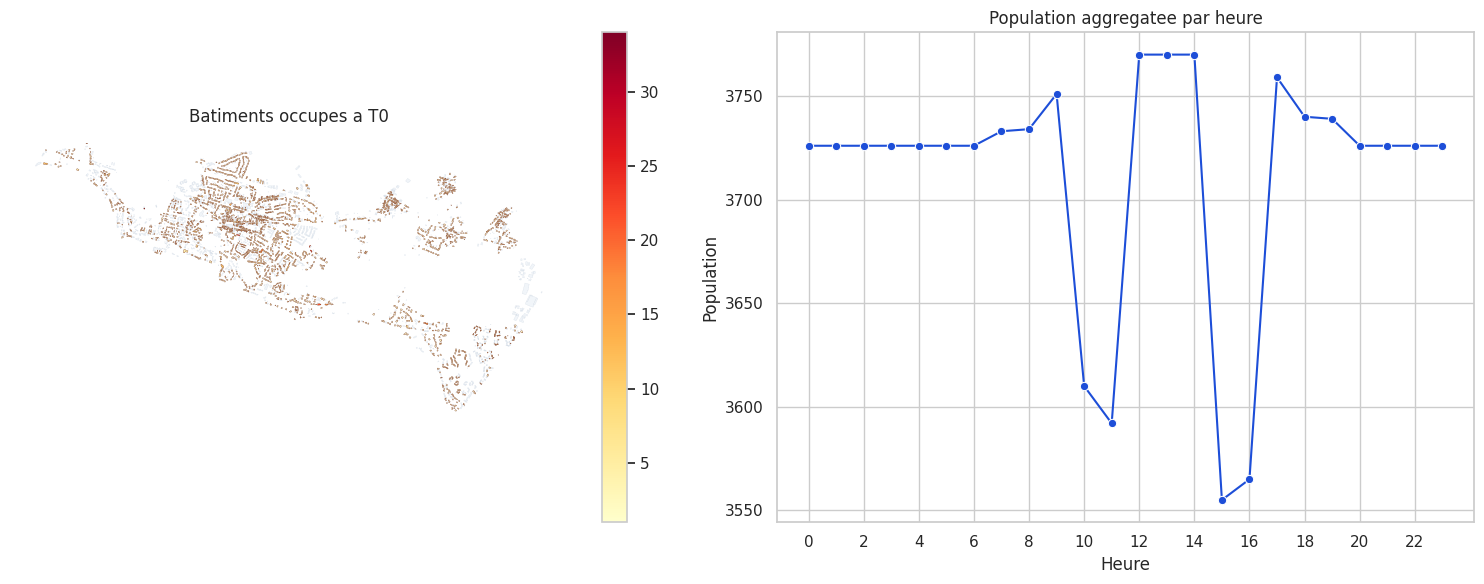

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

gdf_t0 = gdf_export[gdf_export["pop_t0"] > 0].copy()
gdf_export.plot(ax=axes[0], color="#f1f5f9", edgecolor="#cbd5e1", linewidth=0.15)
gdf_t0.plot(ax=axes[0], column="pop_t0", cmap="YlOrRd", legend=True, linewidth=0.2, edgecolor="#7c2d12")
axes[0].set_title("Batiments occupes a T0")
axes[0].axis("off")

sns.lineplot(data=hourly, x="hour", y="population", marker="o", color="#1d4ed8", ax=axes[1])
axes[1].set_title("Population aggregatee par heure")
axes[1].set_xlabel("Heure")
axes[1].set_ylabel("Population")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()


## Types de batiments destination

Ce graphe permet de voir vers quels types de batiments les agents sont principalement diriges.


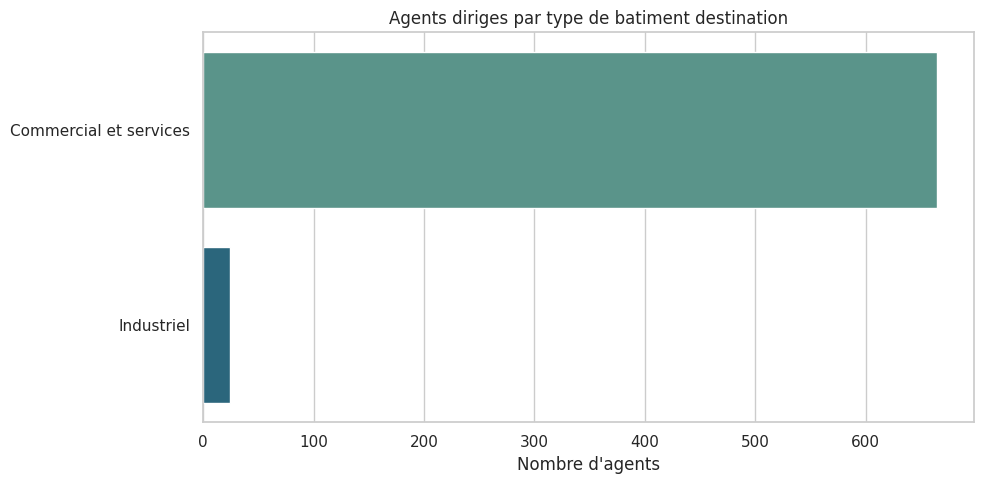

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=type_counts,
    x="agent_count",
    y="destination_usage_group",
    hue="destination_usage_group",
    palette="crest",
    legend=False,
)
plt.title("Agents diriges par type de batiment destination")
plt.xlabel("Nombre d'agents")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Roles et types de destination

La heatmap ci-dessous est utile pour voir si les affectations restent coherentes avec la logique metier.


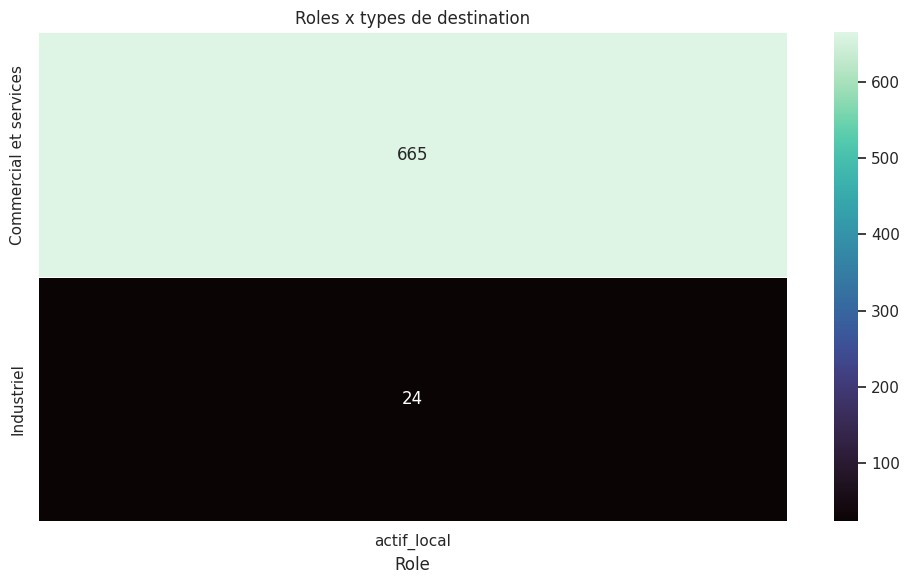

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(role_heatmap, cmap="mako", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Roles x types de destination")
plt.xlabel("Role")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Principaux batiments destination

On combine ici un petit tableau et une carte simple pour identifier les poles d'arrivee les plus importants.


,destination_building_id,destination_usage_1,agent_count
0,BATZ_BATIMENT0000000327816606,Commercial et services,27
1,BATZ_BATIMENT0000000303001176,Commercial et services,18
2,BATZ_BATIMENT0000000303003507,Commercial et services,29
3,BATZ_BATIMENT0000000303004372,Commercial et services,22
4,BATZ_BATIMENT0000002477594836,Commercial et services,51
5,BATZ_BATIMENT0000000303004115,Commercial et services,22
6,BATZ_BATIMENT0000000327816607,Commercial et services,95
7,BATZ_BATIMENT0000000303003866,Commercial et services,17
8,BATZ_BATIMENT0000000303004735,Commercial et services,17
9,BATZ_BATIMENT0000000303000534,Commercial et services,20


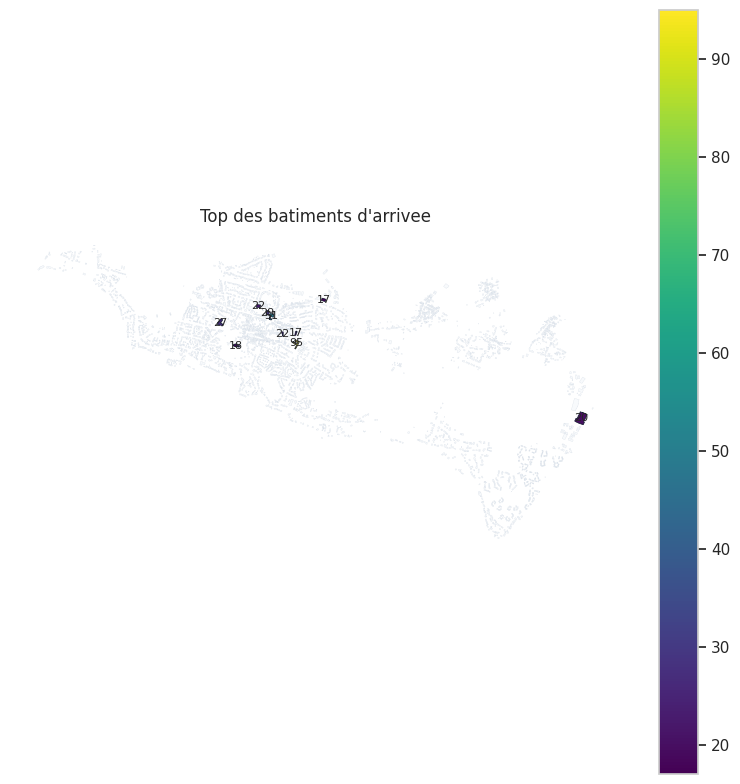

In [11]:
display(top_destinations[["destination_building_id", "destination_usage_1", "agent_count"]])

fig, ax = plt.subplots(figsize=(8, 8))
gdf_model.plot(ax=ax, color="#f8fafc", edgecolor="#cbd5e1", linewidth=0.15)
top_destinations.plot(ax=ax, column="agent_count", cmap="viridis", legend=True, edgecolor="#0f172a", linewidth=0.5)

for _, row in top_destinations.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, str(int(row["agent_count"])), fontsize=8, ha="center", va="center")

ax.set_title("Top des batiments d'arrivee")
ax.axis("off")
plt.tight_layout()
plt.show()
